In [10]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense

In [11]:
with open("handwritten_notes.txt", "r", encoding="utf-8") as file:
    text = file.read()

print("Dataset Loaded Successfully")
print("Total Characters:", len(text))
print("\nFirst 300 Characters:\n")
print(text[:300])

Dataset Loaded Successfully
Total Characters: 1111115

First 300 Characters:

Believe in yourself and never give up.
The engineer wrote the schedule because practice matters.
The engineer reviewed a new project before dinner.
My family prepared the homework without any distractions.
I started the assignment because practice matters.
The student wrote the shopping list with gr


In [12]:
vocab = sorted(set(text))

print("Vocabulary Size:", len(vocab))

char2idx = {u:i for i,u in enumerate(vocab)}
idx2char = np.array(vocab)

text_as_int = np.array([char2idx[c] for c in text])

print("Encoding Completed")

Vocabulary Size: 43
Encoding Completed


In [13]:
sequence_length = 40

char_dataset = tf.data.Dataset.from_tensor_slices(text_as_int)

sequences = char_dataset.batch(sequence_length+1, drop_remainder=True)

In [14]:
def split_input_target(chunk):
    input_text = chunk[:-1]
    target_text = chunk[1:]
    return input_text, target_text

dataset = sequences.map(split_input_target)

In [15]:
BUFFER_SIZE = 5000
BATCH_SIZE = 32

dataset = (
    dataset
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE, drop_remainder=True)
)

In [16]:
vocab_size = len(vocab)

model = Sequential([

    Embedding(vocab_size,64),

    GRU(
        128,
        return_sequences=True
    ),

    Dense(vocab_size)

])

In [17]:
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model.compile(
    optimizer='adam',
    loss=loss,
    metrics=['accuracy']
)

In [18]:
history = model.fit(
    dataset,
    epochs=5
)

Epoch 1/5
846/846 ━━━━━━━━━━━━━━━━━━━━ 27s 30ms/step - accuracy: 0.7419 - loss: 0.9202
Epoch 2/5
846/846 ━━━━━━━━━━━━━━━━━━━━ 25s 29ms/step - accuracy: 0.9067 - loss: 0.2640
Epoch 3/5
846/846 ━━━━━━━━━━━━━━━━━━━━ 25s 29ms/step - accuracy: 0.9089 - loss: 0.2474
Epoch 4/5
846/846 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.9092 - loss: 0.2417
Epoch 5/5
846/846 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.9094 - loss: 0.2388


In [19]:
def generate_text(model, start_string, num_generate=300, temperature=0.8):

    input_eval = [char2idx[s] for s in start_string]

    input_eval = tf.expand_dims(input_eval,0)

    text_generated=[]

    for i in range(num_generate):

        predictions = model(input_eval)

        predictions = tf.squeeze(predictions,0)

        predictions = predictions / temperature

        predicted_id = tf.random.categorical(
            predictions[-1:],1
        )[0,0].numpy()

        input_eval = tf.expand_dims([predicted_id],0)

        text_generated.append(idx2char[predicted_id])

    return start_string + ''.join(text_generated)

In [20]:
print(generate_text(model,"Dear Friend"))

Dear Friend, t ie chere s w finend are plearrthe pre t wopr e al arind ing te the esthe prereariedu pryory orng nister le cowomprore thedineprste gond eacl henfred ashesuplleve die le inepon mangsere Licoreareaniclamuthe cur bede aridedexppre cearereanice p.
The e wherany serngshe ding d le benfiching tecerer 


In [21]:
model.save("handwritten_generator.keras")

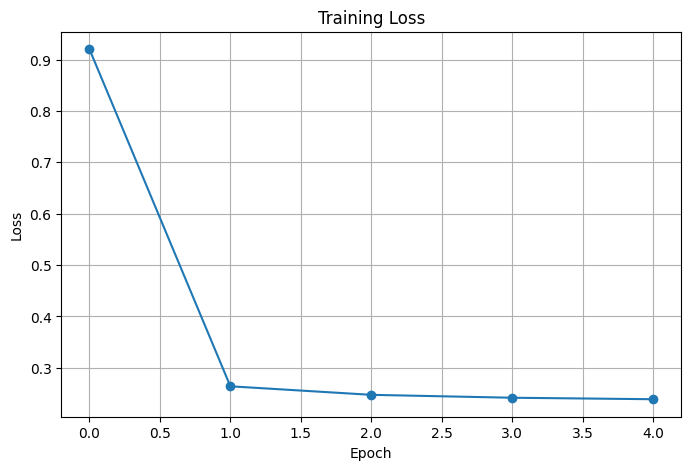

In [22]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

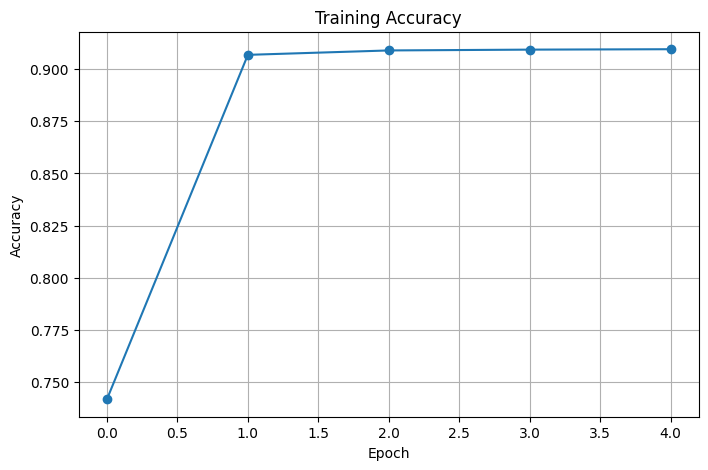

In [23]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], marker='o')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

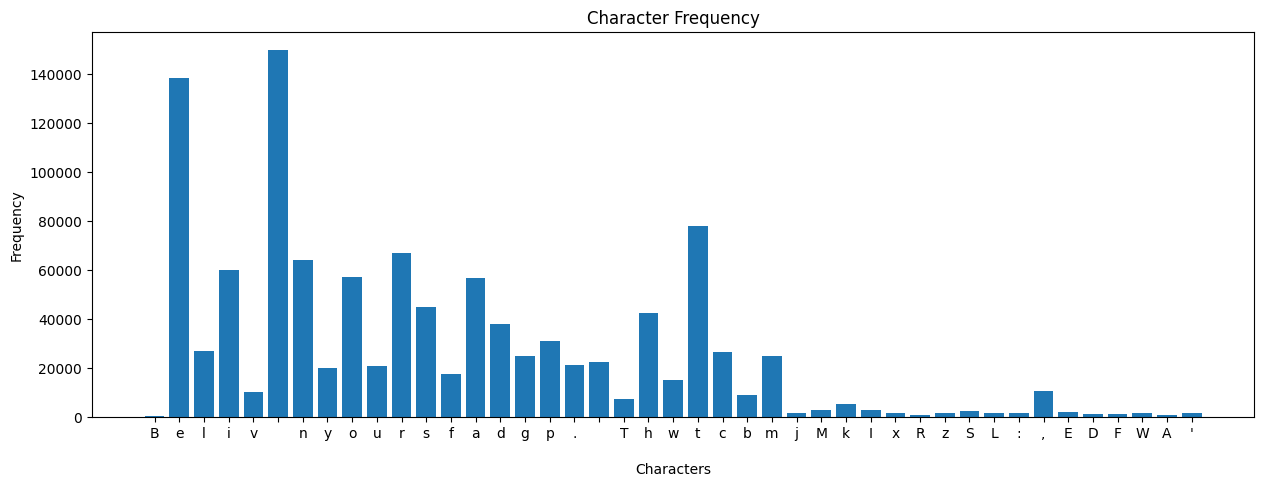

In [24]:
from collections import Counter

counter = Counter(text)

characters = list(counter.keys())
counts = list(counter.values())

plt.figure(figsize=(15,5))
plt.bar(characters,counts)
plt.title("Character Frequency")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

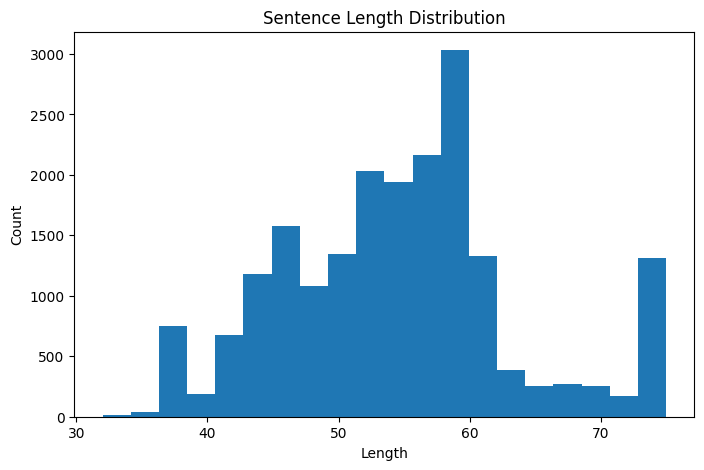

In [25]:
lengths = [len(line) for line in text.split("\n") if line]

plt.figure(figsize=(8,5))
plt.hist(lengths,bins=20)
plt.title("Sentence Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

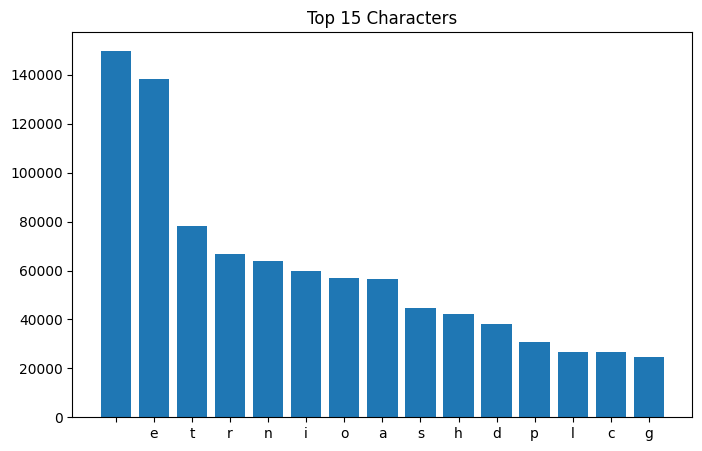

In [26]:
top = counter.most_common(15)

labels = [x[0] for x in top]
values = [x[1] for x in top]

plt.figure(figsize=(8,5))
plt.bar(labels,values)
plt.title("Top 15 Characters")
plt.show()